In [ ]:
# ============================================
# 1. IMPORT REQUIRED LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Load the dataset
df = pd.read_csv("HCP_master_updated.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [ ]:
# ============================================
# 2. DATASET OVERVIEW
# ============================================

print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nLast 5 Records:")
display(df.tail())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(500, 12)

First 5 Records:


,hcp_id,first_name,last_name,specialty,segment,territory,city,state,practice_type,account_tenure,opt_out_flag,channel_preference
0,1,Danielle,Johnson,endocrinology,medium_value,TERR_19,Nashville,TN,hospital,0.5,False,Digital-Heavy
1,2,Joshua,Walker,cardiology,low_value,TERR_40,Detroit,MI,private_practice,3.3,False,In-Person-Heavy
2,3,Jill,Rhodes,cardiology,medium_value,TERR_21,Tucson,AZ,private_practice,0.8,False,Mixed
3,4,Patricia,Miller,endocrinology,high_value,TERR_25,Arlington,TX,clinic,5.6,False,Digital-Heavy
4,5,Robert,Johnson,cardiology,low_value,TERR_47,Oakland,CA,hospital,2.7,False,Mixed



Last 5 Records:


,hcp_id,first_name,last_name,specialty,segment,territory,city,state,practice_type,account_tenure,opt_out_flag,channel_preference
495,496,Robert,Garcia,dermatology,medium_value,TERR_10,Wichita,KS,private_practice,3.3,False,Digital-Heavy
496,497,Tracy,Russell,dermatology,low_value,TERR_30,Dallas,TX,clinic,2.9,False,In-Person-Heavy
497,498,Stephanie,Johnson,dermatology,low_value,TERR_37,Omaha,NE,private_practice,3.1,False,Mixed
498,499,Mitchell,Ramos,primary_care,medium_value,TERR_47,New Orleans,LA,private_practice,0.5,False,In-Person-Heavy
499,500,Stephanie,Foley,oncology,medium_value,TERR_41,San Antonio,TX,cancer_center,1.2,False,In-Person-Heavy



Column Names:
['hcp_id', 'first_name', 'last_name', 'specialty', 'segment', 'territory', 'city', 'state', 'practice_type', 'account_tenure', 'opt_out_flag', 'channel_preference']

Data Types:
hcp_id                  int64
first_name             object
last_name              object
specialty              object
segment                object
territory              object
city                   object
state                  object
practice_type          object
account_tenure        float64
opt_out_flag             bool
channel_preference     object
dtype: object


In [ ]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   hcp_id              500 non-null    int64  
 1   first_name          500 non-null    object 
 2   last_name           500 non-null    object 
 3   specialty           500 non-null    object 
 4   segment             500 non-null    object 
 5   territory           500 non-null    object 
 6   city                500 non-null    object 
 7   state               500 non-null    object 
 8   practice_type       500 non-null    object 
 9   account_tenure      500 non-null    float64
 10  opt_out_flag        500 non-null    bool   
 11  channel_preference  500 non-null    object 
dtypes: bool(1), float64(1), int64(1), object(9)
memory usage: 43.6+ KB


In [ ]:
# ============================================
# 3. COLUMN TYPE IDENTIFICATION
# ============================================

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()
boolean_columns = df.select_dtypes(include='bool').columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nBoolean Columns:")
print(boolean_columns)

Numerical Columns:
['hcp_id', 'account_tenure']

Categorical Columns:
['first_name', 'last_name', 'specialty', 'segment', 'territory', 'city', 'state', 'practice_type', 'channel_preference']

Boolean Columns:
['opt_out_flag']


In [ ]:
# ============================================
# 4. MISSING VALUE ANALYSIS
# ============================================

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

display(missing_summary)

,Missing Count,Missing Percentage
hcp_id,0,0.0
first_name,0,0.0
last_name,0,0.0
specialty,0,0.0
segment,0,0.0
territory,0,0.0
city,0,0.0
state,0,0.0
practice_type,0,0.0
account_tenure,0,0.0


In [ ]:
# ============================================
# 5. DUPLICATE ANALYSIS
# ============================================

# Complete duplicate rows
duplicate_rows = df.duplicated().sum()

print("Number of Completely Duplicate Rows:", duplicate_rows)

Number of Completely Duplicate Rows: 0


In [ ]:
print("\nTotal HCP Records:", len(df))
print("Unique HCP IDs:", df['hcp_id'].nunique())


Total HCP Records: 500
Unique HCP IDs: 500


In [ ]:
# ============================================
# 6. UNIQUE VALUE ANALYSIS
# ============================================

unique_summary = pd.DataFrame({
    'Column': df.columns,
    'Unique Values': [df[col].nunique() for col in df.columns]
})

display(unique_summary)

,Column,Unique Values
0,hcp_id,500
1,first_name,247
2,last_name,325
3,specialty,5
4,segment,3
5,territory,50
6,city,50
7,state,30
8,practice_type,4
9,account_tenure,72


In [ ]:
# Display unique values for categorical columns

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


first_name:
['Danielle' 'Joshua' 'Jill' 'Patricia' 'Robert' 'Jeffery' 'Anthony'
 'Debra' 'Jeffrey' 'Lisa' 'Linda' 'Matthew' 'Susan' 'Christopher'
 'Melanie' 'Lindsay' 'Amanda' 'Nicholas' 'Maria' 'Michelle' 'Janet'
 'Jeremy' 'Craig' 'Cynthia' 'Mitchell' 'Joseph' 'Deborah' 'George' 'Frank'
 'Veronica' 'Angela' 'Megan' 'Leslie' 'Jason' 'Nancy' 'Diana' 'Robin'
 'Anna' 'Brenda' 'Reginald' 'Whitney' 'Daniel' 'Laura' 'Bryan' 'Wendy'
 'Tasha' 'Alexander' 'Erin' 'Shawn' 'Vincent' 'Rita' 'Kenneth' 'Chelsea'
 'Kathryn' 'Kimberly' 'Aaron' 'Andrew' 'Natasha' 'Kyle' 'Natalie' 'Chad'
 'Katie' 'Thomas' 'Rodney' 'Amber' 'James' 'Wanda' 'Samuel' 'David'
 'Jerry' 'Michele' 'John' 'Selena' 'Lindsey' 'Collin' 'Jessica' 'Tracey'
 'Richard' 'Scott' 'Andrea' 'Yvette' 'Tanya' 'Melinda' 'Todd' 'Spencer'
 'Eric' 'Amy' 'Brian' 'Wesley' 'Brooke' 'Joe' 'Pamela' 'Alexandra' 'Emily'
 'Charles' 'Yolanda' 'Nicole' 'Mike' 'Martha' 'Cheryl' 'Destiny'
 'Elizabeth' 'Dennis' 'Jennifer' 'Tracy' 'Meghan' 'Adam' 'Dana' 'Joyce

In [ ]:
# ============================================
# 7. DESCRIPTIVE STATISTICS
# ============================================

numerical_analysis_columns = ['account_tenure']

display(df[numerical_analysis_columns].describe())

,account_tenure
count,500.000000
mean,2.670600
std,1.784524
min,0.500000
25%,1.300000
50%,2.400000
75%,3.700000
max,9.800000


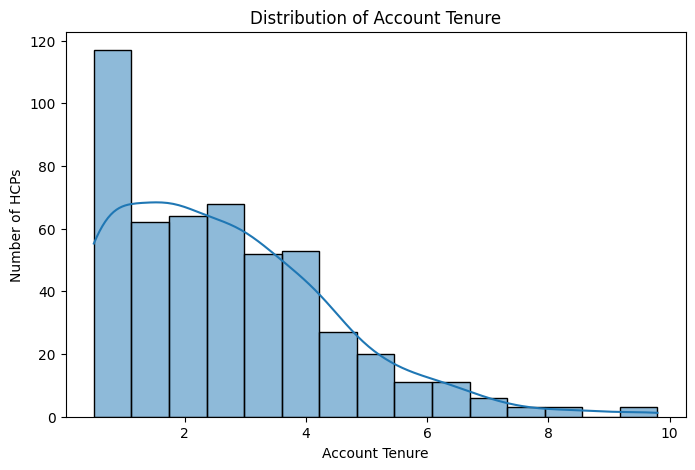

In [ ]:
# ============================================
# 8. ACCOUNT TENURE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.histplot(
    df['account_tenure'],
    bins=15,
    kde=True
)

plt.title("Distribution of Account Tenure")
plt.xlabel("Account Tenure")
plt.ylabel("Number of HCPs")

plt.show()

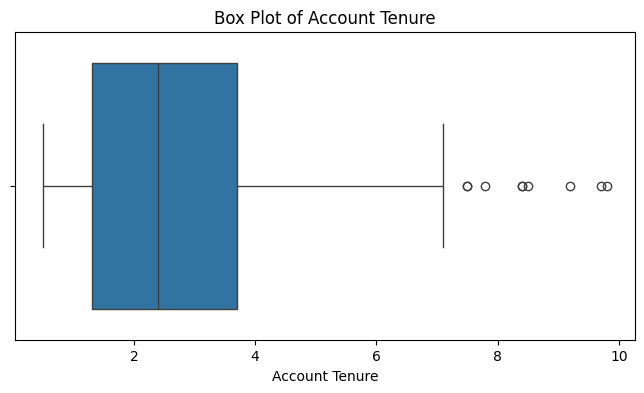

In [ ]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df['account_tenure'])

plt.title("Box Plot of Account Tenure")
plt.xlabel("Account Tenure")

plt.show()

In [ ]:
# ============================================
# 9. OUTLIER DETECTION
# ============================================

Q1 = df['account_tenure'].quantile(0.25)
Q3 = df['account_tenure'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['account_tenure'] < lower_bound) |
    (df['account_tenure'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("\nNumber of Potential Outliers:", len(outliers))

display(outliers)

Q1: 1.3
Q3: 3.7
IQR: 2.4000000000000004

Lower Bound: -2.3000000000000007
Upper Bound: 7.300000000000001

Number of Potential Outliers: 9


,hcp_id,first_name,last_name,specialty,segment,territory,city,state,practice_type,account_tenure,opt_out_flag,channel_preference
102,103,Todd,Lewis,cardiology,medium_value,TERR_39,Atlanta,GA,private_practice,7.5,False,In-Person-Heavy
112,113,Brian,Silva,dermatology,high_value,TERR_30,Miami,FL,private_practice,8.4,False,In-Person-Heavy
116,117,Brooke,Leonard,cardiology,medium_value,TERR_15,Oklahoma City,OK,hospital,7.5,False,In-Person-Heavy
145,146,Adam,Wise,cardiology,high_value,TERR_10,Virginia Beach,VA,private_practice,8.5,False,Mixed
147,148,Joyce,Arnold,endocrinology,medium_value,TERR_48,Houston,TX,clinic,9.8,False,Mixed
189,190,Lee,Charles,dermatology,medium_value,TERR_08,Cleveland,OH,clinic,9.7,False,Digital-Heavy
232,233,Amber,Taylor,endocrinology,high_value,TERR_20,Kansas City,MO,hospital,7.8,False,Mixed
234,235,Jasmine,Brown,cardiology,high_value,TERR_18,Tulsa,OK,clinic,8.4,False,In-Person-Heavy
431,432,Heather,Berger,primary_care,medium_value,TERR_33,Portland,OR,private_practice,9.2,False,Digital-Heavy


In [ ]:
# ============================================
# 10. CATEGORICAL FREQUENCY ANALYSIS
# ============================================

important_categorical_columns = [
    'specialty',
    'segment',
    'territory',
    'city',
    'state',
    'practice_type',
    'channel_preference'
]

for column in important_categorical_columns:

    print("\n" + "=" * 50)
    print(f"Frequency Distribution: {column}")
    print("=" * 50)

    print(df[column].value_counts())


Frequency Distribution: specialty
specialty
primary_care     112
dermatology      102
endocrinology    100
cardiology        96
oncology          90
Name: count, dtype: int64

Frequency Distribution: segment
segment
medium_value    170
low_value       165
high_value      165
Name: count, dtype: int64

Frequency Distribution: territory
territory
TERR_47    17
TERR_08    16
TERR_37    15
TERR_29    15
TERR_46    15
TERR_19    14
TERR_30    13
TERR_49    13
TERR_28    13
TERR_13    12
TERR_23    12
TERR_10    12
TERR_40    11
TERR_42    11
TERR_32    11
TERR_44    11
TERR_36    11
TERR_39    11
TERR_15    11
TERR_43    10
TERR_20    10
TERR_34    10
TERR_38    10
TERR_11    10
TERR_09    10
TERR_14    10
TERR_25    10
TERR_07    10
TERR_02    10
TERR_12     9
TERR_01     9
TERR_27     9
TERR_21     9
TERR_41     9
TERR_26     9
TERR_18     8
TERR_05     8
TERR_35     8
TERR_17     8
TERR_24     8
TERR_33     8
TERR_16     7
TERR_45     7
TERR_06     7
TERR_22     7
TERR_04     7
TERR_48 

In [ ]:
# ============================================
# 11. CATEGORICAL PERCENTAGE DISTRIBUTION
# ============================================

for column in important_categorical_columns:

    print("\n" + "=" * 50)
    print(f"Percentage Distribution: {column}")
    print("=" * 50)

    percentage = df[column].value_counts(normalize=True) * 100

    display(
        percentage.round(2).to_frame(name='Percentage')
    )


Percentage Distribution: specialty


,Percentage
specialty,
primary_care,22.4
dermatology,20.4
endocrinology,20.0
cardiology,19.2
oncology,18.0



Percentage Distribution: segment


,Percentage
segment,
medium_value,34.0
low_value,33.0
high_value,33.0



Percentage Distribution: territory


...

,Percentage
state,
CA,14.8
TX,12.8
AZ,7.0
TN,5.0
NC,4.8
OH,4.6
OK,4.4
CO,4.0
FL,3.4



Percentage Distribution: practice_type


,Percentage
practice_type,
private_practice,49.0
hospital,24.2
clinic,20.4
cancer_center,6.4



Percentage Distribution: channel_preference


,Percentage
channel_preference,
Digital-Heavy,40.2
In-Person-Heavy,31.4
Mixed,28.4


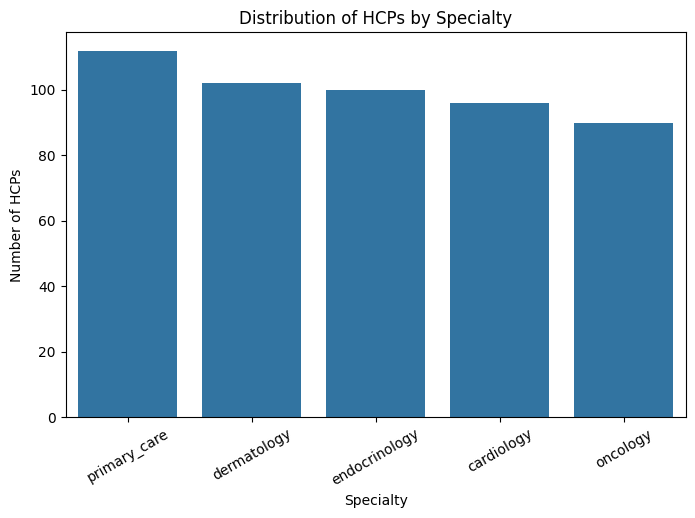

In [ ]:
# ============================================
# 12. SPECIALTY DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='specialty',
    order=df['specialty'].value_counts().index
)

plt.title("Distribution of HCPs by Specialty")
plt.xlabel("Specialty")
plt.ylabel("Number of HCPs")

plt.xticks(rotation=30)

plt.show()

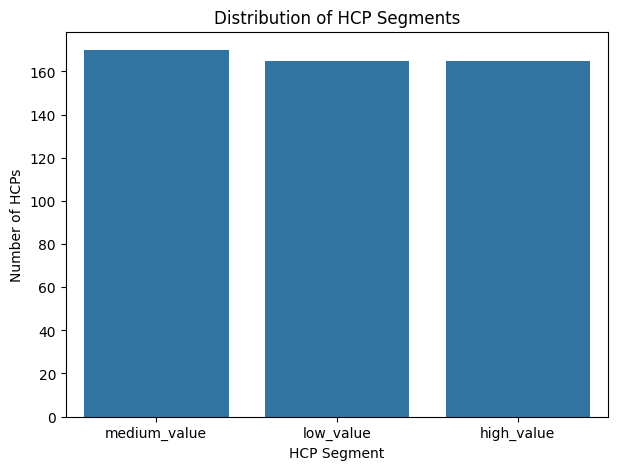

In [ ]:
# ============================================
# 13. HCP SEGMENT DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='segment',
    order=df['segment'].value_counts().index
)

plt.title("Distribution of HCP Segments")
plt.xlabel("HCP Segment")
plt.ylabel("Number of HCPs")

plt.show()

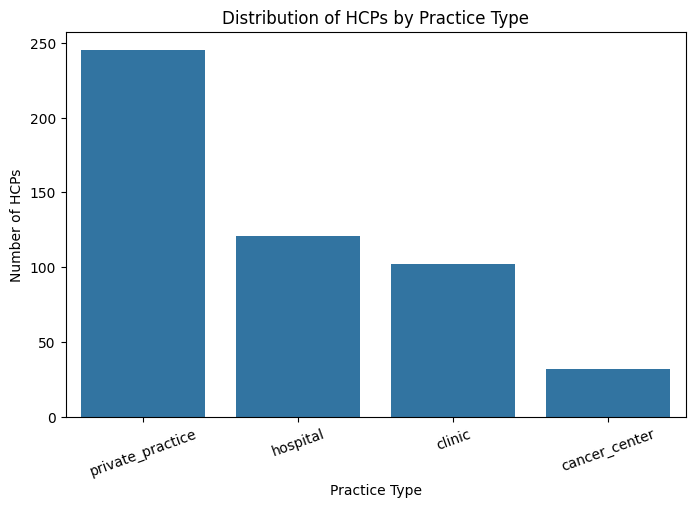

In [ ]:
# ============================================
# 14. PRACTICE TYPE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='practice_type',
    order=df['practice_type'].value_counts().index
)

plt.title("Distribution of HCPs by Practice Type")
plt.xlabel("Practice Type")
plt.ylabel("Number of HCPs")

plt.xticks(rotation=20)

plt.show()

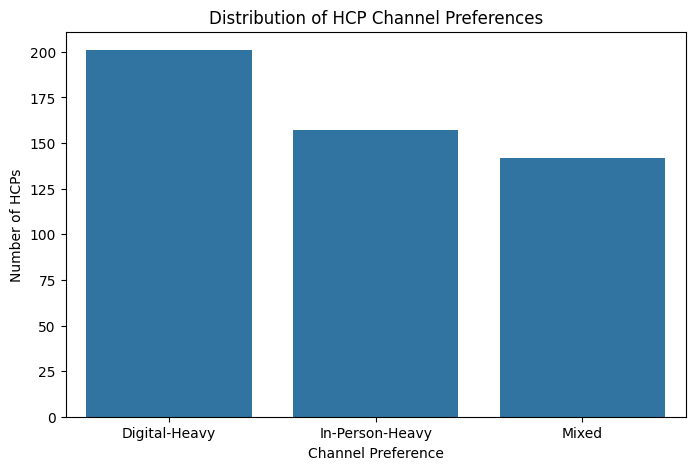

In [ ]:
# ============================================
# 15. CHANNEL PREFERENCE DISTRIBUTION
# ============================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='channel_preference',
    order=df['channel_preference'].value_counts().index
)

plt.title("Distribution of HCP Channel Preferences")
plt.xlabel("Channel Preference")
plt.ylabel("Number of HCPs")

plt.show()

In [ ]:
# ============================================
# 16. OPT-OUT ANALYSIS
# ============================================

print("Opt-Out Frequency:")
print(df['opt_out_flag'].value_counts())

print("\nOpt-Out Percentage:")
print(
    (df['opt_out_flag'].value_counts(normalize=True) * 100).round(2)
)

Opt-Out Frequency:
opt_out_flag
False    462
True      38
Name: count, dtype: int64

Opt-Out Percentage:
opt_out_flag
False    92.4
True      7.6
Name: proportion, dtype: float64


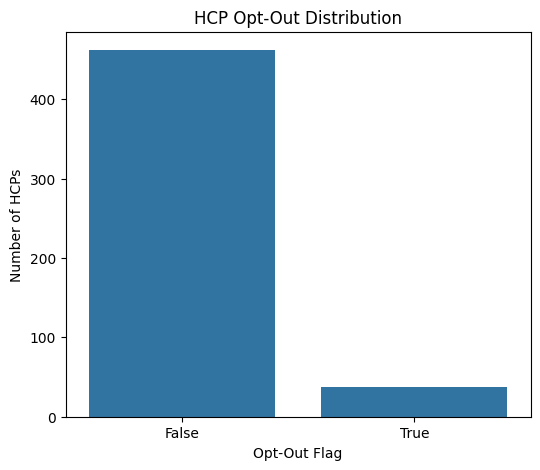

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x='opt_out_flag'
)

plt.title("HCP Opt-Out Distribution")
plt.xlabel("Opt-Out Flag")
plt.ylabel("Number of HCPs")

plt.show()

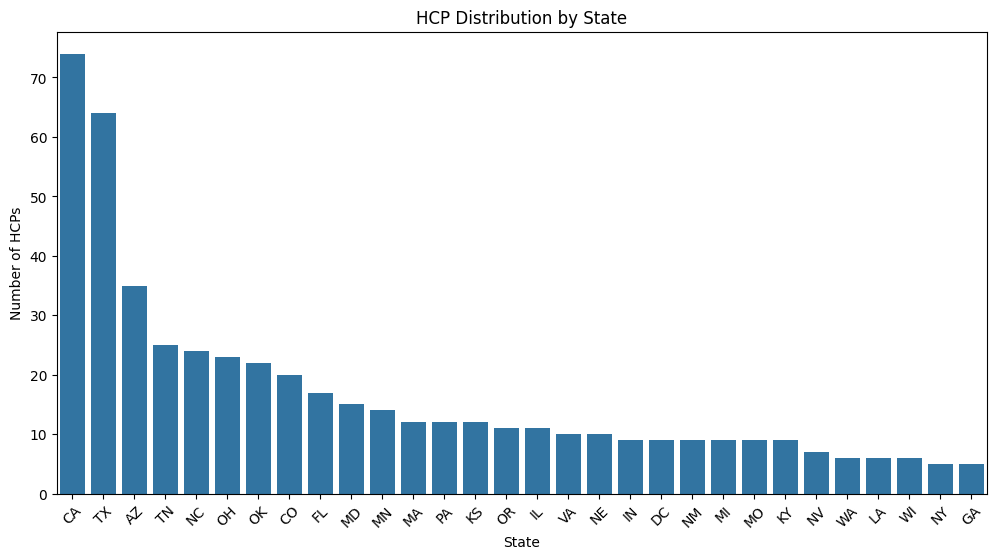

In [ ]:
# ============================================
# 17. GEOGRAPHIC DISTRIBUTION
# ============================================

state_counts = df['state'].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

plt.title("HCP Distribution by State")
plt.xlabel("State")
plt.ylabel("Number of HCPs")

plt.xticks(rotation=45)

plt.show()

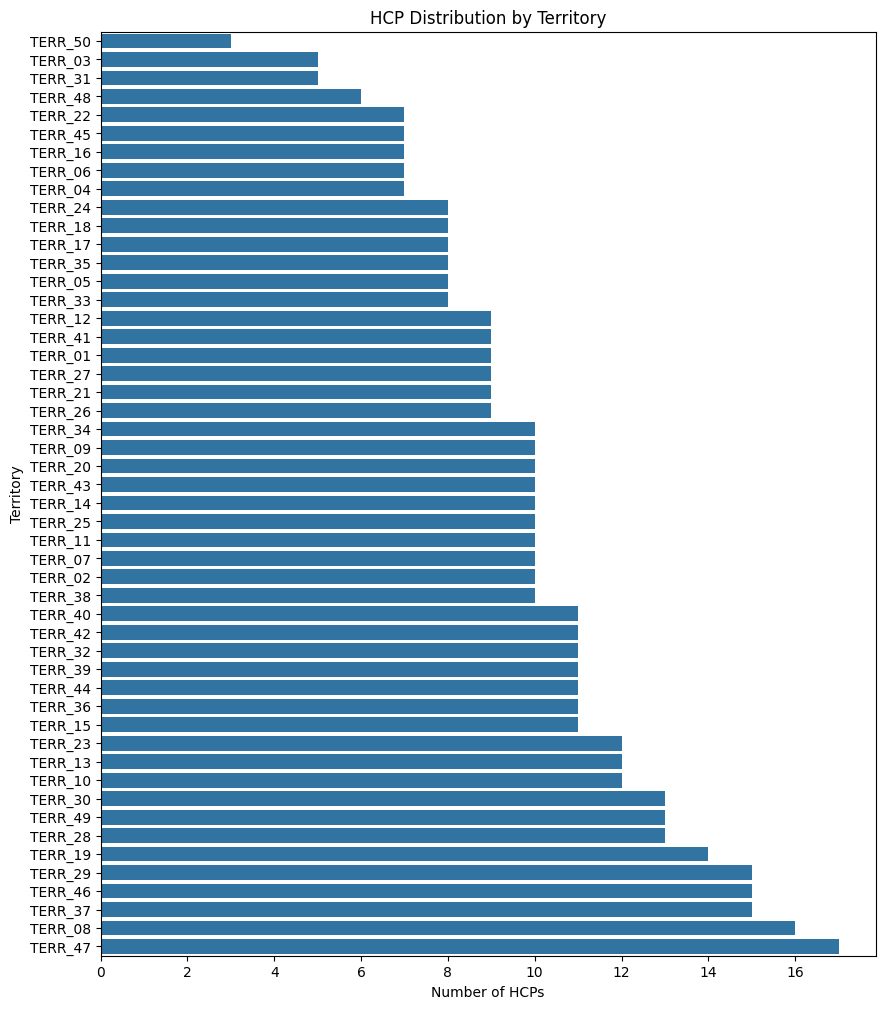

In [ ]:
territory_counts = df['territory'].value_counts().sort_values()

plt.figure(figsize=(10, 12))

sns.barplot(
    x=territory_counts.values,
    y=territory_counts.index
)

plt.title("HCP Distribution by Territory")
plt.xlabel("Number of HCPs")
plt.ylabel("Territory")

plt.show()

In [ ]:
# ============================================
# 19. SEGMENT × PRACTICE TYPE
# ============================================

segment_practice = pd.crosstab(
    df['practice_type'],
    df['segment']
)

display(segment_practice)

segment,high_value,low_value,medium_value
practice_type,,,
cancer_center,10,10,12
clinic,32,28,42
hospital,38,40,43
private_practice,85,87,73


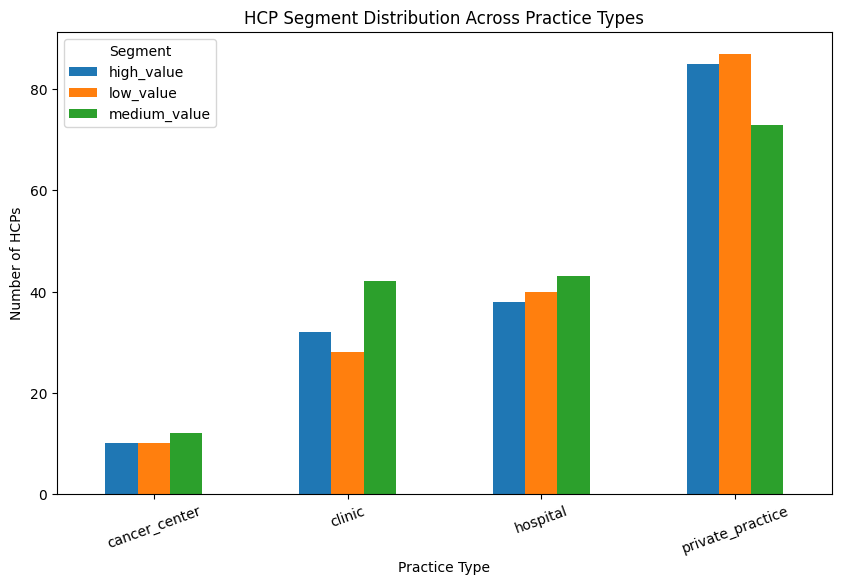

In [ ]:
segment_practice.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("HCP Segment Distribution Across Practice Types")
plt.xlabel("Practice Type")
plt.ylabel("Number of HCPs")

plt.xticks(rotation=20)
plt.legend(title="Segment")

plt.show()

In [ ]:
# ============================================
# 20. SEGMENT × CHANNEL PREFERENCE
# ============================================

segment_channel = pd.crosstab(
    df['segment'],
    df['channel_preference']
)

display(segment_channel)

channel_preference,Digital-Heavy,In-Person-Heavy,Mixed
segment,,,
high_value,71,47,47
low_value,68,58,39
medium_value,62,52,56


In [ ]:
segment_channel_percentage = pd.crosstab(
    df['segment'],
    df['channel_preference'],
    normalize='index'
) * 100

display(segment_channel_percentage.round(2))

channel_preference,Digital-Heavy,In-Person-Heavy,Mixed
segment,,,
high_value,43.03,28.48,28.48
low_value,41.21,35.15,23.64
medium_value,36.47,30.59,32.94


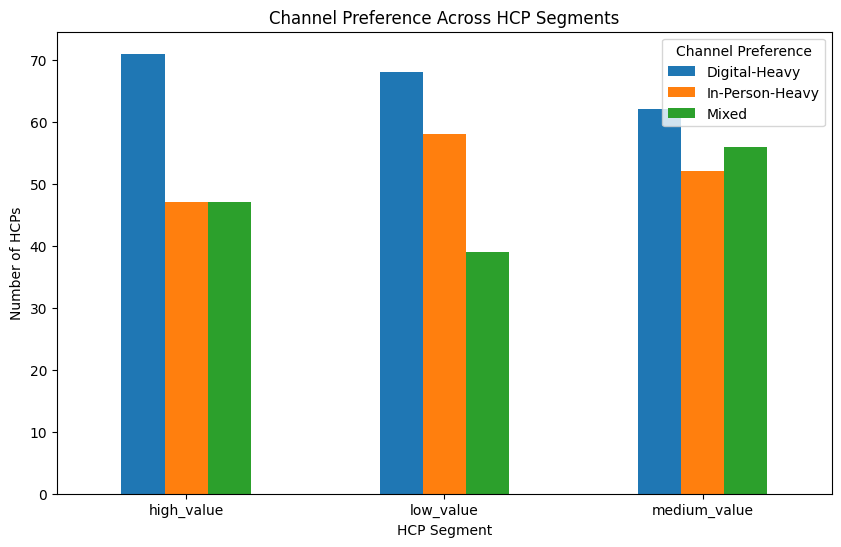

In [ ]:
segment_channel.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Channel Preference Across HCP Segments")
plt.xlabel("HCP Segment")
plt.ylabel("Number of HCPs")

plt.xticks(rotation=0)
plt.legend(title="Channel Preference")

plt.show()

In [ ]:
# ============================================
# 21. PRACTICE TYPE × CHANNEL PREFERENCE
# ============================================

practice_channel = pd.crosstab(
    df['practice_type'],
    df['channel_preference']
)

display(practice_channel)

channel_preference,Digital-Heavy,In-Person-Heavy,Mixed
practice_type,,,
cancer_center,16,9,7
clinic,39,33,30
hospital,53,38,30
private_practice,93,77,75


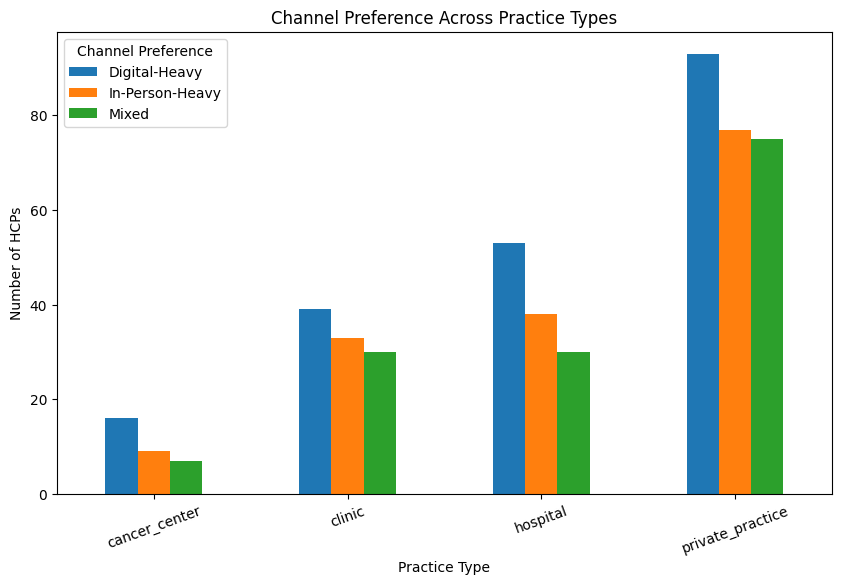

In [ ]:
practice_channel.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Channel Preference Across Practice Types")
plt.xlabel("Practice Type")
plt.ylabel("Number of HCPs")

plt.xticks(rotation=20)
plt.legend(title="Channel Preference")

plt.show()

In [ ]:
# ============================================
# 22. ACCOUNT TENURE × SEGMENT
# ============================================

tenure_segment = df.groupby('segment')['account_tenure'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
)

display(tenure_segment.round(2))

,count,mean,median,min,max,std
segment,,,,,,
high_value,165,2.71,2.4,0.5,8.5,1.86
low_value,165,2.55,2.3,0.5,7.1,1.64
medium_value,170,2.75,2.5,0.5,9.8,1.85


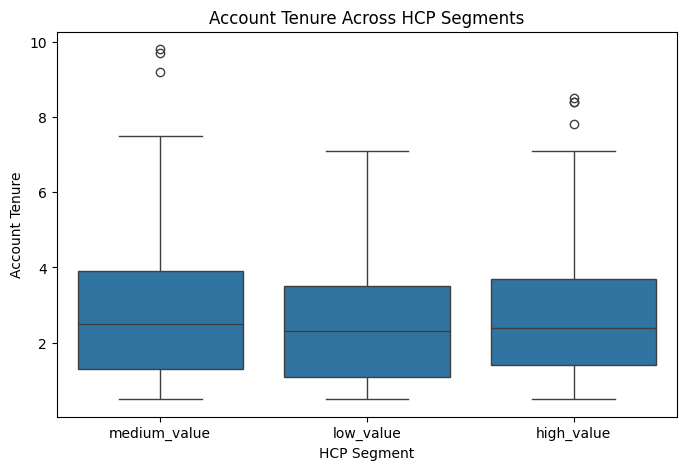

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='segment',
    y='account_tenure'
)

plt.title("Account Tenure Across HCP Segments")
plt.xlabel("HCP Segment")
plt.ylabel("Account Tenure")

plt.show()

In [ ]:
# ============================================
# 23. ACCOUNT TENURE × PRACTICE TYPE
# ============================================

tenure_practice = df.groupby('practice_type')['account_tenure'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
)

display(tenure_practice.round(2))

,count,mean,median,min,max,std
practice_type,,,,,,
cancer_center,32,2.36,2.25,0.5,7.0,1.74
clinic,102,2.73,2.40,0.5,9.8,1.92
hospital,121,2.70,2.70,0.5,7.8,1.62
private_practice,245,2.67,2.40,0.5,9.2,1.82


In [ ]:
# ============================================
# 23. ACCOUNT TENURE × PRACTICE TYPE
# ============================================

tenure_practice = df.groupby('practice_type')['account_tenure'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
)

display(tenure_practice.round(2))

,count,mean,median,min,max,std
practice_type,,,,,,
cancer_center,32,2.36,2.25,0.5,7.0,1.74
clinic,102,2.73,2.40,0.5,9.8,1.92
hospital,121,2.70,2.70,0.5,7.8,1.62
private_practice,245,2.67,2.40,0.5,9.2,1.82


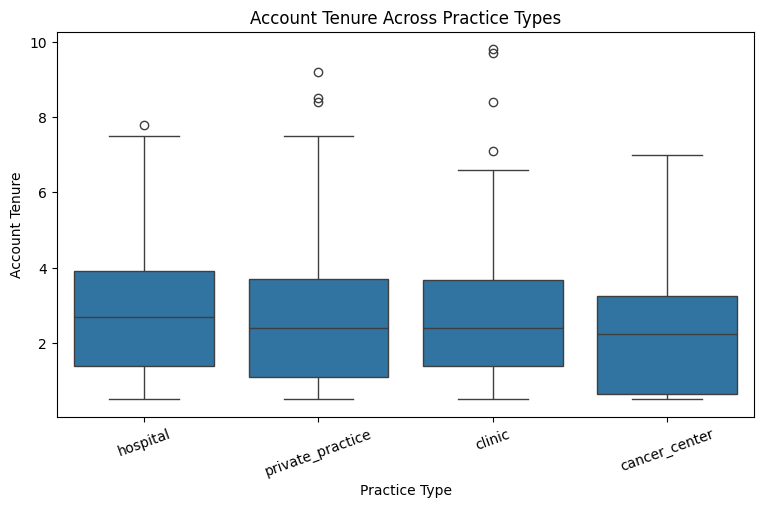

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='practice_type',
    y='account_tenure'
)

plt.title("Account Tenure Across Practice Types")
plt.xlabel("Practice Type")
plt.ylabel("Account Tenure")

plt.xticks(rotation=20)

plt.show()

In [ ]:
# ============================================
# 24. ACCOUNT TENURE × CHANNEL PREFERENCE
# ============================================

tenure_channel = df.groupby('channel_preference')['account_tenure'].agg(
    ['count', 'mean', 'median', 'min', 'max', 'std']
)

display(tenure_channel.round(2))

,count,mean,median,min,max,std
channel_preference,,,,,,
Digital-Heavy,201,2.76,2.7,0.5,9.7,1.71
In-Person-Heavy,157,2.73,2.3,0.5,8.4,1.80
Mixed,142,2.49,2.1,0.5,9.8,1.86


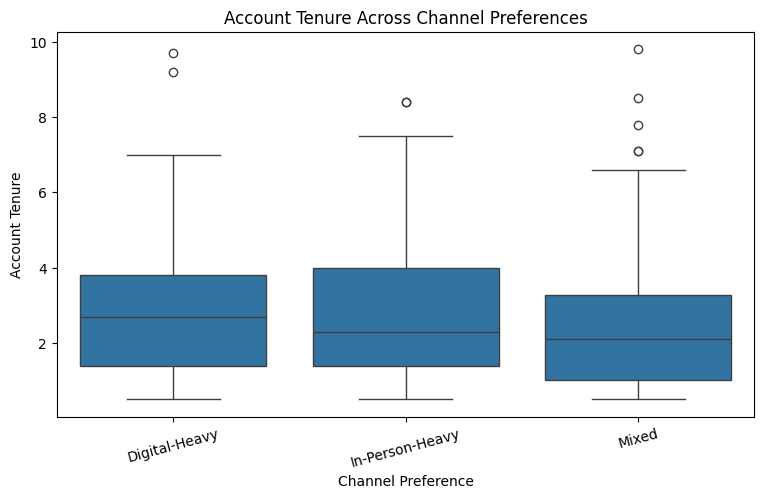

In [ ]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='channel_preference',
    y='account_tenure'
)

plt.title("Account Tenure Across Channel Preferences")
plt.xlabel("Channel Preference")
plt.ylabel("Account Tenure")

plt.xticks(rotation=15)

plt.show()

In [ ]:
# ============================================
# 25. DATA CONSISTENCY CHECK
# ============================================

for column in categorical_columns:

    print("\n" + "=" * 50)
    print(f"Consistency Check: {column}")
    print("=" * 50)

    # Check leading/trailing spaces
    spaces = df[column].astype(str).str.strip().ne(df[column].astype(str))

    print("Values with leading/trailing spaces:", spaces.sum())

    # Check case-normalized unique values
    normalized_values = df[column].astype(str).str.strip().str.lower().nunique()

    print("Original unique values:", df[column].nunique())
    print("Case-normalized unique values:", normalized_values)


Consistency Check: first_name
Values with leading/trailing spaces: 0
Original unique values: 247
Case-normalized unique values: 247

Consistency Check: last_name
Values with leading/trailing spaces: 0
Original unique values: 325
Case-normalized unique values: 325

Consistency Check: specialty
Values with leading/trailing spaces: 0
Original unique values: 5
Case-normalized unique values: 5

Consistency Check: segment
Values with leading/trailing spaces: 0
Original unique values: 3
Case-normalized unique values: 3

Consistency Check: territory
Values with leading/trailing spaces: 0
Original unique values: 50
Case-normalized unique values: 50

Consistency Check: city
Values with leading/trailing spaces: 0
Original unique values: 50
Case-normalized unique values: 50

Consistency Check: state
Values with leading/trailing spaces: 0
Original unique values: 30
Case-normalized unique values: 30

Consistency Check: practice_type
Values with leading/trailing spaces: 0
Original unique values: 4
C

In [ ]:
# ============================================
# 26. DOMAIN VALIDATION
# ============================================

# HCP ID validation
print("Missing HCP IDs:", df['hcp_id'].isnull().sum())
print("Duplicate HCP IDs:", df['hcp_id'].duplicated().sum())

# Account tenure validation
print("\nNegative Account Tenure Values:",
      (df['account_tenure'] < 0).sum())

# Boolean validation
print("\nOpt-Out Values:")
print(df['opt_out_flag'].unique())

# Channel preference validation
print("\nChannel Preference Values:")
print(df['channel_preference'].unique())

# Segment validation
print("\nSegment Values:")
print(df['segment'].unique())

Missing HCP IDs: 0
Duplicate HCP IDs: 0

Negative Account Tenure Values: 0

Opt-Out Values:
[False  True]

Channel Preference Values:
['Digital-Heavy' 'In-Person-Heavy' 'Mixed']

Segment Values:
['medium_value' 'low_value' 'high_value']


In [ ]:
# ============================================
# 27. FINAL EDA SUMMARY
# ============================================

print("=" * 60)
print("HCP MASTER DATASET — EDA SUMMARY")
print("=" * 60)

print("\nDataset Shape:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique HCP IDs:")
print(df['hcp_id'].nunique())

print("\nAccount Tenure:")
print(f"Mean   : {df['account_tenure'].mean():.2f}")
print(f"Median : {df['account_tenure'].median():.2f}")
print(f"Min    : {df['account_tenure'].min():.2f}")
print(f"Max    : {df['account_tenure'].max():.2f}")

print("\nHCP Segment Distribution:")
print(df['segment'].value_counts())

print("\nChannel Preference Distribution:")
print(df['channel_preference'].value_counts())

print("\nOpt-Out Distribution:")
print(df['opt_out_flag'].value_counts())

print("\nSpecialty Distribution:")
print(df['specialty'].value_counts())

print("\nEDA Completed Successfully.")

HCP MASTER DATASET — EDA SUMMARY

Dataset Shape:
Rows    : 500
Columns : 12

Missing Values:
0

Duplicate Rows:
0

Unique HCP IDs:
500

Account Tenure:
Mean   : 2.67
Median : 2.40
Min    : 0.50
Max    : 9.80

HCP Segment Distribution:
segment
medium_value    170
low_value       165
high_value      165
Name: count, dtype: int64

Channel Preference Distribution:
channel_preference
Digital-Heavy      201
In-Person-Heavy    157
Mixed              142
Name: count, dtype: int64

Opt-Out Distribution:
opt_out_flag
False    462
True      38
Name: count, dtype: int64

Specialty Distribution:
specialty
primary_care     112
dermatology      102
endocrinology    100
cardiology        96
oncology          90
Name: count, dtype: int64

EDA Completed Successfully.
